<a href="https://colab.research.google.com/github/hanbiphyun/ESSA_YB/blob/main/ESAA_OB_week11_1_GRU%2C%20%EC%96%91%EB%B0%A9%ED%96%A5%20RNN%20%ED%95%84%EC%82%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

딥러닝 파이토치 교과서
p417~440

###7.6 게이트 순환 신경망(GRU)

**7.6.1 GRU 구조**
- GRU : LSTM에서 사용하는 망각 게이트와 입력게이트를 하나로 합친것
  - 별도의 업데이트 게이트로 구성됨
  - 하나의 게이트 컨트롤러가 망각, 입력 게이트 모두 제어
    - 1 : 망각 게이트 열림, 입력 게이트 닫힘
    - 0 : 망각 게이트 닫힘, 입력 게이트 열림
    - 이전 기억이 저장될때마다 단계별 입력 삭제
  - 출력게이트 X, 전체 상태 벡터가 매 단계마다 출력 -> 이전 상태 어느 부분이 출력될지 제어하는 새 게이트 컨트롤러 존재

1. 망각 게이트
- 과거 정보 적당히 초기화
- 출력값 : 시그모이드 -> 이전 은닉층(과거 정보)에 곱함
> $r_t= σ(W_r·[h_t-1, x_t])$

![image.png](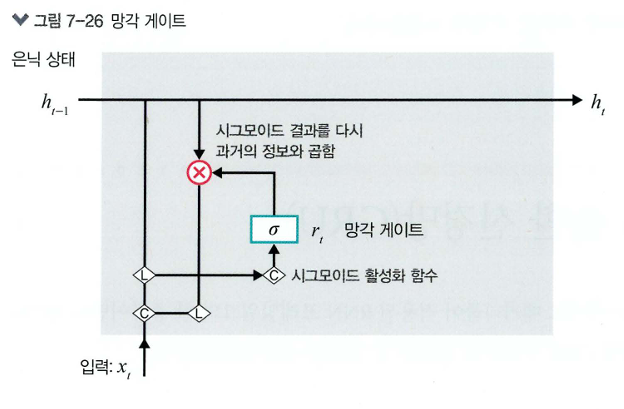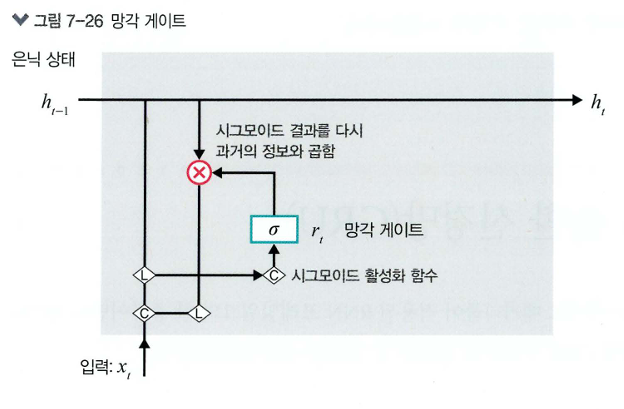)

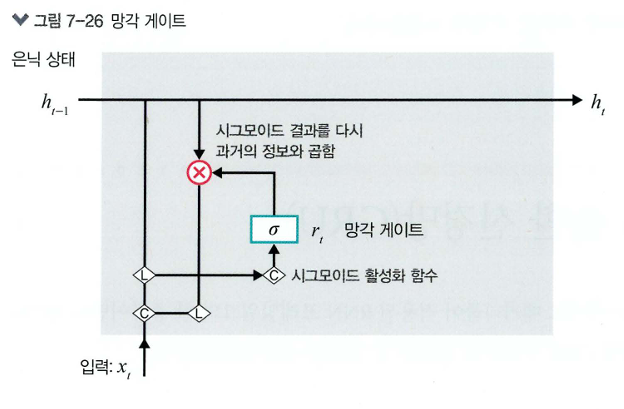


2. 업데이트 게이트
- 과거와 현재 정보의 최신화 비율 결정
- Zt는 현시점의 정보량 결정, (1-Zt)를 직전 은닉층 정보와 곱함
> Zt =σ(Wz.[ht-1, xt])

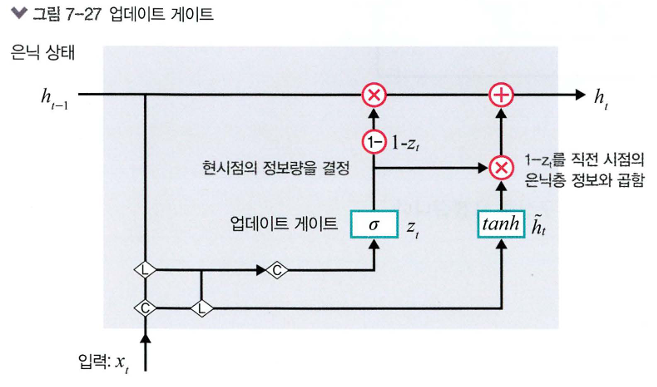

3. 후보군
- 현시점의 정보에 대한 후보군 계산
- 망각 게이트의 결과를 이용하여 후보군 계산
> ~ht = tanh(W. [rt * ht-1, Xt])

4. 은닉층 계산
- 업데이트 게이트 결과와 후보군 결과를 결합해 현시점의 은닉층 계산
- 시그모이드 함수 결과 = 현시점 결과에 대한 정보량, 1-시그모이드 결과 = 과거의 정보량
> ht = (1-Zt) * ht-1 + Zt x ~ht

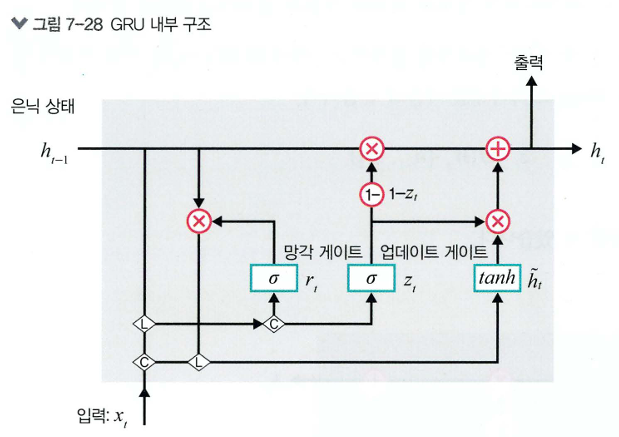

**7.6.2 GRU 셀 구현**
- 네트워크 차이점 위주로 학습

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# 라이브러리 호출
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dataset
from torch.autograd import Variable
from torch.nn import Parameter
from torch import Tensor
import torch.nn .functional as F
from torch.utils.data import DataLoader
import math

device= torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
cuda= True if torch.cuda.is_available() else False

Tensor= torch.cuda.FloatTensor if cuda else torch.FloatTensor

torch.manual_seed(125)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(125)

In [5]:
# 데이터 전처리
# 평균, 표준편차 정규화
# 텐서로 변경
mnist_transform= transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (1.0,))
])

In [20]:
# 데이터셋 내려받기 및 전처리 적용
from torchvision.datasets import MNIST
download_root= '/content/drive/MyDrive/ESSA/MNIST/MNIST'

train_dataset= MNIST(download_root, transform= mnist_transform , train=True, download=True)
valid_dataset= MNIST(download_root, transform= mnist_transform, train=False, download=True)
test_dataset= MNIST(download_root, transform= mnist_transform, train=False, download=True)


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.87MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 160kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.70MB/s]


In [21]:
# 데이터셋 메모리로 가져오기
batch_size= 64
train_loader= DataLoader(dataset= train_dataset,
                         batch_size= batch_size,
                         shuffle= True)
valid_loader= DataLoader(dataset= train_dataset,
                         batch_size= batch_size,
                         shuffle= True)
test_loader= DataLoader(dataset= train_dataset,
                         batch_size= batch_size,
                         shuffle= True)

In [22]:
from IPython.utils.text import num_ini_spaces
# 변수 값 설정
batch_size= 100
n_iters= 6000
num_epochs= n_iters/ (len(train_dataset)/ batch_size)
num_epochs= int(num_epochs)

In [23]:
# GRU 셀 네트워크
class GRUCell(nn.Module):
    def __init__(self, input_size, hidden_size, bias=True):
        super(GRUCell, self).__init__()
        self.input_size= input_size
        self.hidden_size= hidden_size
        self.bias= bias
        self.x2h= nn.Linear(input_size, 3*hidden_size, bias=bias)
        self.h2h= nn.Linear(hidden_size, 3*hidden_size, bias=bias)
        self.reset_parameters()

    # 파라미터 초기화
    def reset_parameters(self):
        std= 1.0 / math.sqrt(self.hidden_size)
        for w in self.parameters():
            w.data.uniform_(-std, std)

    def forward(self, x, hidden):
        x= x.view(-1, x.size(1))

        # LSTM 셀에서는 gates를 x2h+h2h로 정의한 것과 다름
        gate_x= self.x2h(x)
        gate_h= self.h2h(hidden)

        gate_x= gate_x.squeeze()
        gate_h= gate_h.squeeze()

        # 3개의 게이트를 위해 쪼갬 (망각, 입력, 새 게이트)
        i_r, i_i, i_n= gate_x.chunk(3,1)
        h_r, h_i, h_n= gate_h.chunk(3,1)

        resetgate= F.sigmoid(i_r+h_r)
        inputgate= F.sigmoid(i_i+ h_i)
        # 새 게이트는 탄젠트 함수 적용됨
        newgate= F.tanh(i_n + (resetgate * h_n))

        hy= newgate+inputgate*(hidden-newgate)
        return hy


In [27]:
# 전반적인 네트워크 구조
class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim, bias=True):
        super(GRUModel, self).__init__()
        self.hidden_dim= hidden_dim
        self.layer_dim= layer_dim

        # 앞에 정의한 셀 함수 불러오기
        self.gru_cell= GRUCell(input_dim, hidden_dim, layer_dim)
        self.fc=nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        if torch.cuda.is_available():
            h0 = Variable(torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).cuda())
        else:
            h0 = Variable(torch.zeros(self.layer_dim, x.size(0), self.hidden_dim ))

        outs = []
        hn = h0 [0,:,:] # LSTM 셀에서는 셀 상태에 대해서도 정의했었지만 GRU 셀에서는 셀은 사용되지 않습니다.

        for seq in range (x.size(1)):
            hn = self.gru_cell(x[: ,seq,:], hn )
            outs.append(hn)
            out= outs[-1].squeeze()
        out= self.fc(out)
        return out

In [28]:
# 옵티마이저와 손실 함수 설정
input_dim= 28
hidden_dim= 128
layer_dim= 1
output_dim=10

model= GRUModel(input_dim, hidden_dim, layer_dim, output_dim)

if torch.cuda.is_available():
    model.cuda()

criterion= nn.CrossEntropyLoss()
learning_rate= 0.1
optimizer= torch.optim.SGD(model.parameters(), lr= learning_rate)

In [29]:
# 모델 학습 및 성능 검증
seq_dim= 28
loss_list=[]
iter= 0

for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        if torch.cuda.is_available():
            images = Variable( images.view(-1 , seq_dim, input_dim).cuda())
            labels = Variable( labels.cuda())
        else:
            images = Variable( images.view(-1, seq_dim, input_dim))
            labels = Variable( labels )

        optimizer.zero_grad()
        outputs = model( images )
        loss = criterion(outputs, labels)

        if torch.cuda.is_available():
            loss.cuda()
        loss.backward()
        optimizer.step()

        loss_list.append(loss.item())
        iter += 1

        if iter % 500 == 0:
            correct = 0
            total = 0
            for images, labels in valid_loader:
                if torch.cuda.is_available():
                    images = Variable(images.view(-1 , seq_dim, input_dim).cuda())
                else:
                    images = Variable(images.view(-1 , seq_dim, input_dim))

                outputs = model( images )
                _, predicted = torch.max(outputs.data, 1)

                total += labels.size(0)

                if torch.cuda.is_available():
                    correct += (predicted.cpu() == labels.cpu()).sum()
                else:
                    correct += (predicted == labels).sum()

            accuracy = 100 * correct / total
            print('Iteration: {}. Loss : {}. Accuracy : {}'.format(iter, loss.item(),accuracy))


Iteration: 500. Loss : 1.3694266080856323. Accuracy : 56.95000076293945
Iteration: 1000. Loss : 0.7073050141334534. Accuracy : 79.45999908447266
Iteration: 1500. Loss : 0.38845548033714294. Accuracy : 89.3949966430664
Iteration: 2000. Loss : 0.16169336438179016. Accuracy : 92.86666870117188
Iteration: 2500. Loss : 0.2894361913204193. Accuracy : 94.76166534423828
Iteration: 3000. Loss : 0.25812962651252747. Accuracy : 93.26667022705078
Iteration: 3500. Loss : 0.18668538331985474. Accuracy : 95.82166290283203
Iteration: 4000. Loss : 0.17531824111938477. Accuracy : 96.16000366210938
Iteration: 4500. Loss : 0.023569755256175995. Accuracy : 96.23833465576172
Iteration: 5000. Loss : 0.05718919634819031. Accuracy : 97.35832977294922
Iteration: 5500. Loss : 0.19438835978507996. Accuracy : 96.76166534423828
Iteration: 6000. Loss : 0.19632314145565033. Accuracy : 97.49833679199219
Iteration: 6500. Loss : 0.03650892525911331. Accuracy : 98.0683364868164
Iteration: 7000. Loss : 0.01332944631576538

In [30]:
# 테스트 데이터셋을 이용한 모델 예측
def evaluate(model, val_iter):
    corrects, total, total_loss = 0, 0, 0
    model.eval()
    for images, labels in val_iter:
        if torch.cuda.is_available():
            images = images.view(-1, seq_dim, input_dim).cuda()
            labels = labels.cuda()
        else:
            images = images.view(-1, seq_dim, input_dim).to(device)
            labels = labels.to(device)

        logit = model(images)
        loss = F.cross_entropy(logit, labels, reduction="sum")

        _, predicted = torch.max(logit.data, 1)
        total += labels.size(0)
        total_loss += loss.item()
        corrects += (predicted == labels).sum().item()

    avg_loss = total_loss / len(val_iter.dataset)
    avg_accuracy = corrects / total
    return avg_loss, avg_accuracy

In [31]:
# 모델 예측 결과
test_loss, test_acc= evaluate(model, test_loader)
print('Test Loss: %5.2f | Test Accuracy: %5.2f' %(test_loss, test_acc))

Test Loss:  0.07 | Test Accuracy:  0.98


**7.3.4 GRU 계층 구현**
- 모델 네트워크 위주로 학습하기

In [32]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.autograd import Variable
from tqdm import tqdm_notebook
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

device = torch .device( 'cuda:0' if torch.cuda.is_available() else 'cpu' )

In [33]:
# 데이터셋 불러오기
data= pd.read_csv('/content/drive/MyDrive/ESSA/SBUX.csv')
print(data.dtypes)

Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object


In [34]:
data['Date']= pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)
data['Volume']= data['Volume'].astype(float)

In [35]:
X= data.iloc[:, :-1]
y= data.iloc[:, 5:6]
print(X)
print(y)

                  Open        High         Low       Close   Adj Close
Date                                                                  
2019-12-11   86.260002   86.870003   85.849998   86.589996   84.145752
2019-12-12   88.000000   88.889999   87.540001   88.209999   85.720032
2019-12-13   88.019997   88.790001   87.580002   88.669998   86.167046
2019-12-16   89.139999   89.300003   88.430000   88.779999   86.273941
2019-12-17   88.870003   88.970001   87.470001   88.129997   85.642288
...                ...         ...         ...         ...         ...
2020-12-04  101.349998  102.940002  101.070000  102.279999  101.442787
2020-12-07  102.010002  102.220001  100.690002  101.410004  100.579918
2020-12-08  100.370003  101.570000  100.010002  101.209999  100.381554
2020-12-09  101.940002  102.209999  100.099998  100.400002   99.578186
2020-12-10  103.510002  106.089996  102.750000  105.389999  104.527336

[253 rows x 5 columns]
                Volume
Date                  
2019-12

In [36]:
# 훈련과 테스트 데이터셋 정규화
ms= MinMaxScaler()
ss= StandardScaler()

X_ss= ss.fit_transform(X)
y_ms= ms.fit_transform(y)

X_train= X_ss[:200, :]
X_test= X_ss[200:, :]

y_train= y_ms[:200, :]
y_test= y_ms[200:, :]

print('Training Shape', X_train.shape, y_train.shape)
print('Testing Shape', X_test.shape, y_test.shape)


Training Shape (200, 5) (200, 1)
Testing Shape (53, 5) (53, 1)


In [43]:
# 데이터셋 형태 변경 -> LSTM 네트워크에 적용하기 위함
X_train_tensors = Variable(torch.Tensor(X_train))
X_test_tensors = Variable(torch.Tensor(X_test))
y_train_tensors = Variable(torch.Tensor(y_train))
y_test_tensors = Variable(torch.Tensor(y_test))

X_train_tensors_f = torch.reshape(X_train_tensors, (X_train_tensors.shape[0], 1, X_train_tensors.shape[1]))
X_test_tensors_f = torch.reshape(X_test_tensors, (X_test_tensors.shape[0],1, X_test_tensors.shape[1]))

print("Training Shape", X_train_tensors_f.shape, y_train_tensors.shape)
print("Testing Shape", X_test_tensors_f.shape, y_test_tensors.shape)

Training Shape torch.Size([200, 1, 5]) torch.Size([200, 1])
Testing Shape torch.Size([53, 1, 5]) torch.Size([53, 1])


In [44]:
# GRU 모델 네트워크
class GRU(nn.Module):
    def __init__(self, num_classes, input_size, hidden_size, num_layers, seq_length):
        super(GRU, self).__init__()
        self.num_classes = num_classes
        self.num_layers = num_layers
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.seq_length = seq_length

        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, batch_first=True)
        self.fc_1 = nn.Linear(hidden_size, 128)
        self.fc = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        h_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size))
        output, (hn) = self.gru(x, (h_0))
        hn = hn.view(-1, self.hidden_size)
        out = self.relu(hn)
        out = self.fc_1(out)
        out = self.relu(out)
        out = self.fc(out)
        return out

In [45]:
# 옵티마이저와 손실 함수 지정
num_epochs = 1000
learning_rate = 0.0001

input_size = 5
hidden_size = 2
num_layers = 1 # GRU 계층의 개수

num_classes = 1
model = GRU(num_classes, input_size, hidden_size, num_layers, X_train_tensors_f.shape[1])

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [46]:
# 모델 학습
for epoch in range(num_epochs):
    outputs = model(X_train_tensors_f)
    optimizer.zero_grad()
    loss = criterion(outputs, y_train_tensors)
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print("Epoch: %d, loss: %1.5f" % (epoch, loss.item()))

Epoch: 0, loss: 0.18281
Epoch: 100, loss: 0.06233
Epoch: 200, loss: 0.03291
Epoch: 300, loss: 0.02834
Epoch: 400, loss: 0.02631
Epoch: 500, loss: 0.02462
Epoch: 600, loss: 0.02329
Epoch: 700, loss: 0.02224
Epoch: 800, loss: 0.02137
Epoch: 900, loss: 0.02063


In [47]:
# 그래프 출력을 위한 전처리
df_x_ss = ss.transform(data.iloc[: , :-1])
df_y_ms = ms.transform(data.iloc[: , -1:])
df_x_ss = Variable(torch.Tensor(df_x_ss ))
df_y_ms = Variable(torch.Tensor( df_y_ms ))
df_x_ss = torch.reshape(df_x_ss, (df_x_ss.shape[0] , 1, df_x_ss.shape[1]))

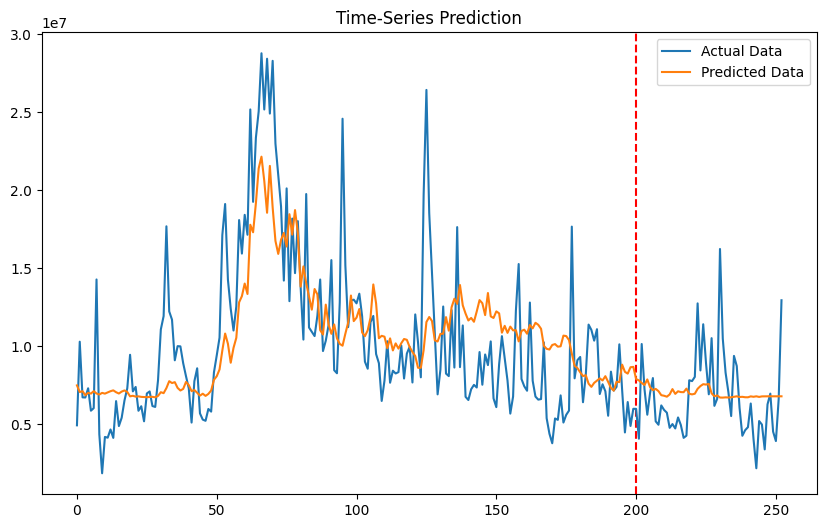

In [48]:
# 모델 예측 결과 출력
train_predict = model(df_x_ss)
predicted = train_predict.data.numpy()

label_y = df_y_ms.data.numpy()
predicted = ms.inverse_transform(predicted)
label_y = ms.inverse_transform(label_y)
plt.figure(figsize=(10,6))
plt.axvline(x=200, c= 'r' , linestyle='--')
plt.plot(label_y, label= 'Actual Data ')
plt.plot(predicted, label= 'Predicted Data' )
plt.title( 'Time-Series Prediction')
plt.legend()
plt.show()

### 7.7 양방향 RNN
: 이전 시점 데이터와 이후 시점의 데이터도 함께 활용하여 출력값 예측하고자 함

**7.7.1 양방향 RNN 구조**
- 하나의 출력값 예측하는데 메모리 셀 2개 사용
  - 첫번째 셀 : 이전 시점의 은닉 상태 전달받아 현재 은닉 상태 계산 (초록 셀)
  - 두번째 셀 : 다음 시점의 은닉 상태를 전달받아 현재 은닉상태 계산 (노란 셀)

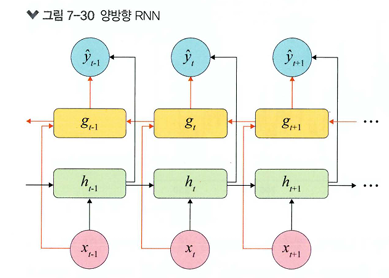

**7.7.2 양방향 LSTM 구현**

In [61]:
# 모델 생성 후 학습
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.autograd import Variable
from tqdm import tqdm_notebook
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

data = pd.read_csv('/content/drive/MyDrive/ESSA/SBUX.csv')
print(data.dtypes)

data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)
data['Volume'] = data['Volume'].astype(float)

X = data.iloc[:, :-1]
y = data.iloc[:, 5:6]

ms = MinMaxScaler()
ss = StandardScaler()

X_ss= ss.fit_transform(X)
y_ms= ms.fit_transform(y)

X_train= X_ss[:200, :]
X_test= X_ss[200:, :]

y_train= y_ms[:200, :]
y_test= y_ms[200:, :]

X_train_tensors = Variable(torch.Tensor(X_train))
X_test_tensors = Variable(torch.Tensor(X_test))
y_train_tensors = Variable(torch.Tensor(y_train))
y_test_tensors = Variable(torch.Tensor(y_test))

X_train_tensors_f = torch.reshape(X_train_tensors, (X_train_tensors.shape[0], 1, X_train_tensors.shape[1]))
X_test_tensors_f = torch.reshape(X_test_tensors, (X_test_tensors.shape[0],1, X_test_tensors.shape[1]))

print("Training Shape", X_train_tensors_f.shape, y_train_tensors.shape)
print("Testing Shape", X_test_tensors_f.shape, y_test_tensors.shape)


Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object
Training Shape torch.Size([200, 1, 5]) torch.Size([200, 1])
Testing Shape torch.Size([53, 1, 5]) torch.Size([53, 1])


In [62]:
# 모델의 네트워크
class biLSTM(nn.Module):
    def __init__(self, num_classes, input_size, hidden_size, num_layers, seq_length):
        super(biLSTM, self).__init__()
        self.num_classes = num_classes
        self.num_layers = num_layers
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.seq_length = seq_length

        # 1
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers, bidirectional=True, batch_first=True)
        # 2
        self.fc = nn.Linear(hidden_size * 2, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        # 2
        h_0 = Variable(torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size))
        c_0 = Variable(torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size))

        out, _ = self.lstm(x, (h_0, c_0))
        out = self.fc(out[:, -1, :])
        out = self.relu(out)
        return out

- #1 : LSTM 계층 정의할때 bidirectional=True 옵션 사용하면 양방향 LSTM 사용하겠다는 뜻 (양방향 RNN, GRU도 동일)
- #2 : 양방향 LSTM 은 입력데이터가 전방향, 역방향 학습에 모두 전달되고 결과도 출력에 반영됨
  - 한번 학습 시 두개의 계층 필요 -> 은닉, 셀 상태에 2 곱하고 출력층에도 2 곱함

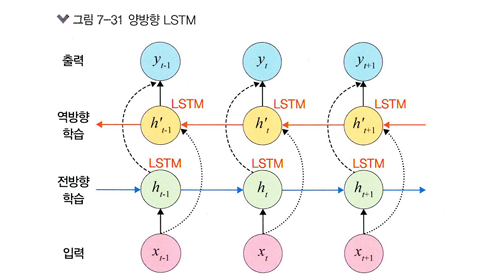

In [63]:
# 모델 학습
num_epochs=1000
learning_rate= 0.0001

input_size= 5
hidden_size= 2
num_layers=1

num_classes = 1
model = biLSTM(num_classes, input_size, hidden_size, num_layers, X_train_tensors_f.shape[1])

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(num_epochs):
    outputs = model(X_train_tensors_f)
    optimizer.zero_grad()
    loss = criterion(outputs, y_train_tensors)
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print("Epoch: %d, loss: %1.5f" % (epoch, loss.item()))

Epoch: 0, loss: 0.06654
Epoch: 100, loss: 0.06189
Epoch: 200, loss: 0.05766
Epoch: 300, loss: 0.05339
Epoch: 400, loss: 0.04892
Epoch: 500, loss: 0.04440
Epoch: 600, loss: 0.04016
Epoch: 700, loss: 0.03643
Epoch: 800, loss: 0.03332
Epoch: 900, loss: 0.03080


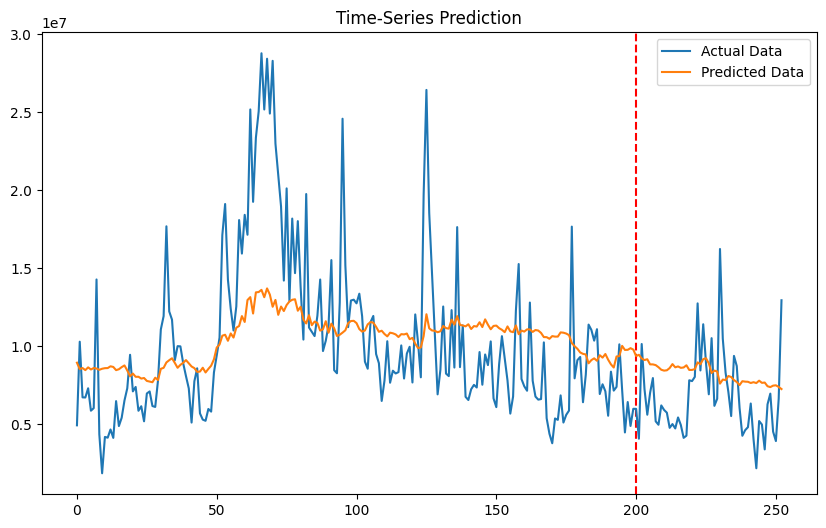

In [64]:
# 모델 평가
df_x_ss = ss.transform(data.iloc[:, :-1])
df_y_ms = ms.transform(data.iloc[:, -1:])

df_x_ss = Variable(torch.Tensor(df_x_ss))
df_y_ms = Variable(torch.Tensor(df_y_ms))

df_x_ss = torch.reshape(df_x_ss, (df_x_ss.shape[0], 1, df_x_ss.shape[1]))

train_predict = model(df_x_ss)
predicted = train_predict.data.numpy()
label_y = df_y_ms.data.numpy()

predicted = ms.inverse_transform(predicted)
label_y = ms.inverse_transform(label_y)

plt.figure(figsize=(10,6))
plt.axvline(x=200, c='r', linestyle='--')

plt.plot(label_y, label='Actual Data')
plt.plot(predicted, label='Predicted Data')
plt.title('Time-Series Prediction')
plt.legend()
plt.show()